In [ ]:
#imports
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict


# Project Code

This notebook is broken up into **Recreating** the paper, and then **Improving** using modern techniques in ML literature.

## Recreation Section

We aim to recreate the results of the paper as close as possible

### Data
*Paper mentions data came from US Postal Service Digits. Found the website here https://hastie.su.domains/StatLearnSparsity_files/DATA/zipcode
(data converted to csv using chatgpt)*

In [ ]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")
train_df.head()

,label,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_247,pixel_248,pixel_249,pixel_250,pixel_251,pixel_252,pixel_253,pixel_254,pixel_255,pixel_256
0,6.0,-1.0,-1.0,-1.0,-1.000,-1.000,-1.000,-1.000,-0.631,0.862,...,0.304,0.823,1.000,0.482,-0.474,-0.991,-1.000,-1.000,-1.000,-1.0
1,5.0,-1.0,-1.0,-1.0,-0.813,-0.671,-0.809,-0.887,-0.671,-0.853,...,-0.671,-0.671,-0.033,0.761,0.762,0.126,-0.095,-0.671,-0.828,-1.0
2,4.0,-1.0,-1.0,-1.0,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,...,-1.000,-1.000,-1.000,-0.109,1.000,-0.179,-1.000,-1.000,-1.000,-1.0
3,7.0,-1.0,-1.0,-1.0,-1.000,-1.000,-0.273,0.684,0.960,0.450,...,-0.318,1.000,0.536,-0.987,-1.000,-1.000,-1.000,-1.000,-1.000,-1.0
4,3.0,-1.0,-1.0,-1.0,-1.000,-1.000,-0.928,-0.204,0.751,0.466,...,0.466,0.639,1.000,1.000,0.791,0.439,-0.199,-0.883,-1.000,-1.0


### Paper Preprocessing
*Paper does some preprocessing to downsize the images. Exact transformations are shown below*

In [ ]:
# Converting names
def load_usps_csv(df):
    y = df["label"].to_numpy().astype(np.int64)
    X = df.drop(columns=["label"]).to_numpy().astype(np.float32)

    assert X.shape[1] == 256, f"Expected 256 pixels, got {X.shape[1]}"

    # reshape into (N, 16, 16)
    X = X.reshape(-1, 16, 16)

    return X, y

X_train_16, y_train = load_usps_csv(train_df)
X_test_16, y_test = load_usps_csv(test_df)

print("Train 16x16:", X_train_16.shape, y_train.shape)
print("Test 16x16:", X_test_16.shape, y_test.shape)
print("Pixel range train:", X_train_16.min(), X_train_16.max())
print("Pixel range test:", X_test_16.min(), X_test_16.max())

Train 16x16: (7291, 16, 16) (7291,)
Test 16x16: (2007, 16, 16) (2007,)
Pixel range train: -1.0 1.0
Pixel range test: -1.0 1.0


In [ ]:
# Embed 16x16 into 28x28
# Paper uses 28x28 actual input plane.
# Put the 16x16 digit in the center.
def embed_16x16_to_28x28(X16, fill_value=-1.0):
    N = X16.shape[0]
    X28 = np.full((N, 28, 28), fill_value, dtype=np.float32)

    # center 16x16 inside 28x28
    start = (28 - 16) // 2   # 6
    end = start + 16         # 22

    X28[:, start:end, start:end] = X16
    return X28

X_train_28 = embed_16x16_to_28x28(X_train_16, fill_value=-1.0)
X_test_28 = embed_16x16_to_28x28(X_test_16, fill_value=-1.0)

print("Train 28x28:", X_train_28.shape)
print("Test 28x28:", X_test_28.shape)

Train 28x28: (7291, 28, 28)
Test 28x28: (2007, 28, 28)


In [ ]:
# Add channel dimension for CNNs
# Final shape: (N, 1, 28, 28)
X_train = X_train_28[:, None, :, :]
X_test = X_test_28[:, None, :, :]

print("CNN train shape:", X_train.shape)
print("CNN test shape:", X_test.shape)

CNN train shape: (7291, 1, 28, 28)
CNN test shape: (2007, 1, 28, 28)


In [ ]:
# Build +/-1 target vectors for paper-style MSE
# correct class = +1, others = -1
def labels_to_pm1_targets(y, num_classes=10):
    T = -np.ones((len(y), num_classes), dtype=np.float32)
    T[np.arange(len(y)), y] = 1.0
    return T

T_train = labels_to_pm1_targets(y_train, num_classes=10)
T_test = labels_to_pm1_targets(y_test, num_classes=10)

print("Target shape:", T_train.shape)
print("Example target for label", y_train[0], ":", T_train[0])

Target shape: (7291, 10)
Example target for label 6 : [-1. -1. -1. -1. -1. -1.  1. -1. -1. -1.]


In [ ]:
# Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

T_train_t = torch.tensor(T_train, dtype=torch.float32)
T_test_t = torch.tensor(T_test, dtype=torch.float32)

In [ ]:
# Dataset object
class USPSPaperDataset(Dataset):
    def __init__(self, X, y, T):
        self.X = X
        self.y = y
        self.T = T

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.T[idx]

train_dataset = USPSPaperDataset(X_train_t, y_train_t, T_train_t)
test_dataset = USPSPaperDataset(X_test_t, y_test_t, T_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

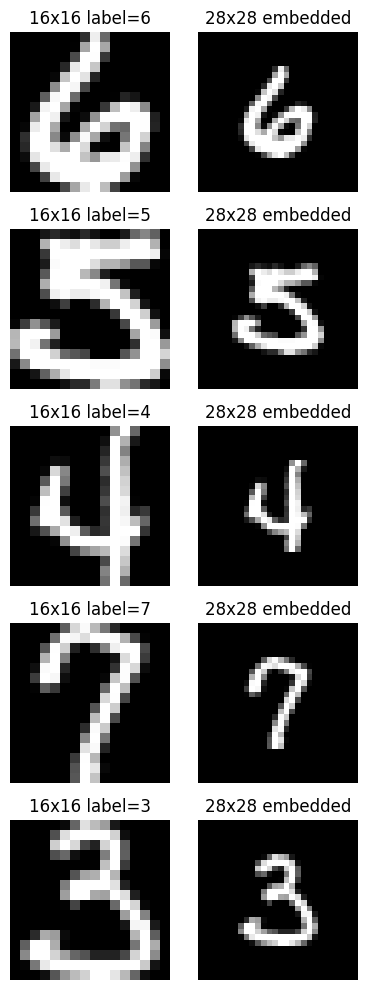

In [ ]:
# Sample Data

def show_samples(X16, X28, y, n=5):
    fig, axes = plt.subplots(n, 2, figsize=(4, 2*n))
    for i in range(n):
        axes[i, 0].imshow(X16[i], cmap="gray", vmin=-1, vmax=1)
        axes[i, 0].set_title(f"16x16 label={y[i]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(X28[i], cmap="gray", vmin=-1, vmax=1)
        axes[i, 1].set_title("28x28 embedded")
        axes[i, 1].axis("off")
    plt.tight_layout()
    plt.show()

show_samples(X_train_16, X_train_28, y_train, n=5)

### Model Architecture

*Below is a description, then implementation of the papers architecture*

*The paper uses their version of a convolution nn, so we implement it as close as possible to their specs*

**The Architecture is as follows:**

0. Input:
1. H1: 4 feature maps, 5x5 Conv, Output 24x24
2. H2: Trainable av subsampling, Output 12x12
3. H3: 12 Feature Maps, 5x5 Conv, Ouptut 8x8
4. H4: Trainable avg subsampling, Output 4x4
5. Output: 10 fully connected Units

In [ ]:
# Subsampling Layer
# each map has:
#   y = a_c * avgpool2x2(x_c) + b_c
# where a_c and b_c are learned per feature map
class TrainableSubsampling(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.a = nn.Parameter(torch.ones(channels))   # scale per map
        self.b = nn.Parameter(torch.zeros(channels))  # bias per map

    def forward(self, x):
        # x: (B, C, H, W)
        x = F.avg_pool2d(x, kernel_size=2, stride=2)
        x = x * self.a.view(1, -1, 1, 1) + self.b.view(1, -1, 1, 1)
        return torch.tanh(x)

# H2 maps are indexed 0..3
# H3 maps are indexed 0..11
#
# Table (paper):
# H3.1  <- H2.1
# H3.2  <- H2.1, H2.2
# H3.3  <- H2.1, H2.2
# H3.4  <- H2.2
# H3.5  <- H2.1, H2.2
# H3.6  <- H2.1, H2.2
# H3.7  <- H2.3
# H3.8  <- H2.3, H2.4
# H3.9  <- H2.3, H2.4
# H3.10 <- H2.4
# H3.11 <- H2.3, H2.4
# H3.12 <- H2.3, H2.4
H3_CONNECTIONS = [
    [0],        # map 1
    [0, 1],     # map 2
    [0, 1],     # map 3
    [1],        # map 4
    [0, 1],     # map 5
    [0, 1],     # map 6
    [2],        # map 7
    [2, 3],     # map 8
    [2, 3],     # map 9
    [3],        # map 10
    [2, 3],     # map 11
    [2, 3],     # map 12
]



class PartialConvH3(nn.Module):
    def __init__(self):
        super().__init__()
        self.convs = nn.ModuleList()

        for in_maps in H3_CONNECTIONS:
            conv = nn.Conv2d(
                in_channels=len(in_maps),
                out_channels=1,
                kernel_size=5,
                stride=1,
                padding=0,
                bias=True
            )
            self.convs.append(conv)

    def forward(self, x):
        # x: (B, 4, 12, 12)
        outs = []
        for in_maps, conv in zip(H3_CONNECTIONS, self.convs):
            x_sub = x[:, in_maps, :, :]         # select connected H2 maps
            y = conv(x_sub)                     # (B, 1, 8, 8)
            outs.append(y)
        y = torch.cat(outs, dim=1)              # (B, 12, 8, 8)
        return torch.tanh(y)


class LeCun1989Exact(nn.Module):
    def __init__(self):
        super().__init__()

        # H1: 1 -> 4 maps, 5x5, 28x28 -> 24x24
        self.h1 = nn.Conv2d(
            in_channels=1,
            out_channels=4,
            kernel_size=5,
            stride=1,
            padding=0,
            bias=True
        )

        # H2: 4 maps, trainable avg subsampling, 24x24 -> 12x12
        self.h2 = TrainableSubsampling(channels=4)

        # H3: 4 maps -> 12 maps with partial connectivity, 12x12 -> 8x8
        self.h3 = PartialConvH3()

        # H4: 12 maps, trainable avg subsampling, 8x8 -> 4x4
        self.h4 = TrainableSubsampling(channels=12)

        # Output: 12*4*4 = 192 -> 10
        self.out = nn.Linear(12 * 4 * 4, 10, bias=True)

    def forward(self, x):
        # x: (B, 1, 28, 28)

        # H1
        x = torch.tanh(self.h1(x))     # (B, 4, 24, 24)

        # H2
        x = self.h2(x)                 # (B, 4, 12, 12)

        # H3
        x = self.h3(x)                 # (B, 12, 8, 8)

        # H4
        x = self.h4(x)                 # (B, 12, 4, 4)

        # Output
        x = x.view(x.size(0), -1)      # (B, 192)
        x = self.out(x)                # (B, 10)

        return x

In [ ]:
# Example impl
model = LeCun1989Exact()

x = torch.randn(8, 1, 28, 28)
y = model(x)

print("output shape:", y.shape)  # should be (8, 10)

num_params = sum(p.numel() for p in model.parameters())
print("num params:", num_params) # should be 2578

output shape: torch.Size([8, 10])
num params: 2578


### Training

*Paper uses MSE and backpropagation for 30 passses*

In [ ]:
#Train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LeCun1989Exact().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():
        for xb, yb, tb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            tb = tb.to(device)

            out = model(xb)
            loss = criterion(out, tb)

            total_loss += loss.item() * xb.size(0)
            total += xb.size(0)

            pred = out.argmax(dim=1)
            correct += (pred == yb).sum().item()

    return total_loss / total, correct / total

train_mse_history = []
test_mse_history = []

for epoch in range(30):
    model.train()
    running_loss = 0.0
    total = 0

    for xb, yb, tb in train_loader:
        xb = xb.to(device)
        tb = tb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, tb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    train_mse, train_acc = evaluate(model, train_loader, criterion)
    test_mse, test_acc = evaluate(model, test_loader, criterion)

    train_mse_history.append(train_mse)
    test_mse_history.append(test_mse)

    print(
        #f"epoch {epoch+1:02d} | "
        f"train_mse={train_mse:.4f} train_err={1-train_acc:.4%} | "
        f"test_mse={test_mse:.4f} test_err={1-test_acc:.4%}"
    )


train_mse=0.2458 train_err=37.1143% | test_mse=0.2496 test_err=39.1131%
train_mse=0.1826 train_err=16.9661% | test_mse=0.1945 test_err=21.7240%
train_mse=0.1611 train_err=13.9213% | test_mse=0.1753 test_err=18.2860%
train_mse=0.1494 train_err=11.1233% | test_mse=0.1646 test_err=15.3961%
train_mse=0.1404 train_err=10.3827% | test_mse=0.1565 test_err=14.4494%
train_mse=0.1322 train_err=9.2717% | test_mse=0.1487 test_err=13.0543%
train_mse=0.1248 train_err=8.2156% | test_mse=0.1417 test_err=11.7090%
train_mse=0.1184 train_err=7.8727% | test_mse=0.1359 test_err=11.2108%
train_mse=0.1111 train_err=6.9126% | test_mse=0.1286 test_err=10.3139%
train_mse=0.1046 train_err=6.5012% | test_mse=0.1223 test_err=9.9651%
train_mse=0.0992 train_err=6.1994% | test_mse=0.1175 test_err=9.5167%
train_mse=0.0938 train_err=5.7194% | test_mse=0.1123 test_err=9.0683%
train_mse=0.0894 train_err=5.2942% | test_mse=0.1083 test_err=8.8191%
train_mse=0.0852 train_err=5.0473% | test_mse=0.1042 test_err=8.4704%
train_

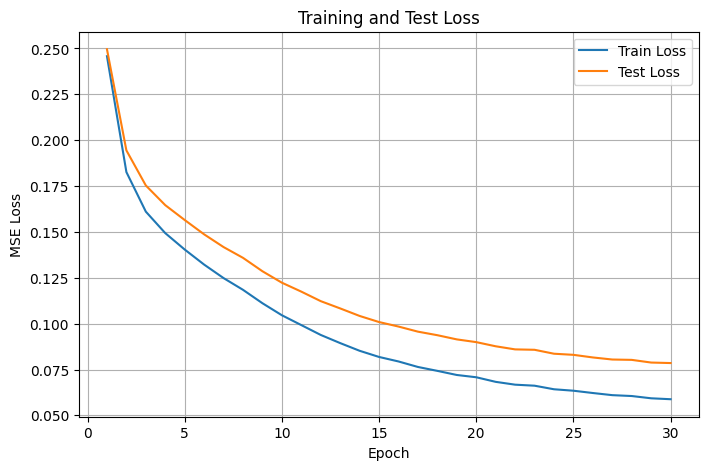

In [ ]:
# Plot train/test loss
epochs = range(1, len(train_mse_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_mse_history, label="Train Loss")
plt.plot(epochs, test_mse_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation Function

*Paper has a few evaluation functions that are used to determine effectiveness of model. Code attempts to recreate those as close as possible*


In [ ]:
def evaluate_with_rejection(model, loader, t1, t2, td, device="cpu"):
    model.eval()

    total = 0
    rejected = 0
    accepted = 0
    accepted_correct = 0

    with torch.no_grad():
        for xb, yb, tb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb)  # (B, 10)

            top2_vals, top2_idx = torch.topk(out, k=2, dim=1)
            top1 = top2_vals[:, 0]
            top2 = top2_vals[:, 1]
            pred = top2_idx[:, 0]

            accept = (top1 > t1) & (top2 < t2) & ((top1 - top2) > td)

            total += xb.size(0)
            rejected += (~accept).sum().item()
            accepted += accept.sum().item()

            if accept.any():
                accepted_correct += (pred[accept] == yb[accept]).sum().item()

    reject_rate = rejected / total
    accept_rate = accepted / total

    if accepted > 0:
        accepted_acc = accepted_correct / accepted
        accepted_err = 1 - accepted_acc
    else:
        accepted_acc = float("nan")
        accepted_err = float("nan")

    return {
        "total": total,
        "accepted": accepted,
        "rejected": rejected,
        "reject_rate": reject_rate,
        "accept_rate": accept_rate,
        "accepted_accuracy": accepted_acc,
        "accepted_error": accepted_err,
    }

In [ ]:
def grid_search_rejection(model, loader, device="cpu"):
    results = []

    t1_vals = np.linspace(-1.0, -0.4, 25)
    t2_vals = np.linspace(-0.2, 0.2, 25)
    td_vals = np.linspace(0.45, 0.8, 36)

    for t1 in t1_vals:
        for t2 in t2_vals:
            for td in td_vals:
                res = evaluate_with_rejection(model, loader, t1, t2, td, device=device)
                res["t1"] = float(t1)
                res["t2"] = float(t2)
                res["td"] = float(td)
                results.append(res)

    return results

### Results

In [ ]:
# Collect full test outputs
def collect_outputs(model, loader, device="cpu"):
    model.eval()

    all_images = []
    all_labels = []
    all_targets = []
    all_outputs = []
    all_preds = []

    with torch.no_grad():
        for xb, yb, tb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            tb = tb.to(device)

            out = model(xb)
            pred = out.argmax(dim=1)

            all_images.append(xb.cpu())
            all_labels.append(yb.cpu())
            all_targets.append(tb.cpu())
            all_outputs.append(out.cpu())
            all_preds.append(pred.cpu())

    images = torch.cat(all_images, dim=0)    # (N, 1, 28, 28)
    labels = torch.cat(all_labels, dim=0)    # (N,)
    targets = torch.cat(all_targets, dim=0)  # (N, 10)
    outputs = torch.cat(all_outputs, dim=0)  # (N, 10)
    preds = torch.cat(all_preds, dim=0)      # (N,)

    return images, labels, targets, outputs, preds


images, labels, targets, outputs, preds = collect_outputs(model, test_loader, device=device)

print("images:", images.shape)
print("labels:", labels.shape)
print("outputs:", outputs.shape)
print("preds:", preds.shape)

images: torch.Size([2007, 1, 28, 28])
labels: torch.Size([2007])
outputs: torch.Size([2007, 10])
preds: torch.Size([2007])


In [ ]:
# Test metrics
def basic_metrics(outputs, labels, targets):
    mse = torch.mean((outputs - targets) ** 2).item()
    acc = (outputs.argmax(dim=1) == labels).float().mean().item()
    err = 1 - acc
    return {"mse": mse, "acc": acc, "err": err}

metrics = basic_metrics(outputs, labels, targets)
print(metrics)

{'mse': 0.0785241425037384, 'acc': 0.9347284436225891, 'err': 0.06527155637741089}


tensor([[352,   0,   1,   0,   2,   1,   1,   1,   1,   0],
        [  0, 258,   0,   0,   3,   0,   3,   0,   0,   0],
        [  7,   1, 176,   3,   6,   1,   0,   1,   3,   0],
        [  1,   0,   4, 153,   1,   5,   0,   1,   0,   1],
        [  0,   2,   4,   0, 183,   0,   2,   1,   0,   8],
        [  4,   0,   0,   6,   1, 145,   0,   0,   1,   3],
        [  3,   0,   2,   0,   4,   3, 158,   0,   0,   0],
        [  0,   0,   1,   1,   8,   0,   0, 135,   0,   2],
        [  4,   3,   2,   6,   1,   4,   1,   0, 145,   0],
        [  0,   1,   0,   1,   1,   0,   0,   2,   1, 171]])


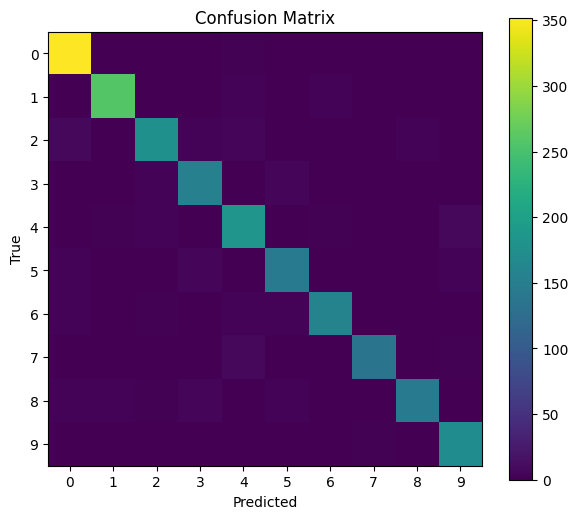

In [ ]:
# Confusion matrix
def confusion_matrix_torch(labels, preds, num_classes=10):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    for y, p in zip(labels, preds):
        cm[y.long(), p.long()] += 1
    return cm

cm = confusion_matrix_torch(labels, preds, num_classes=10)
print(cm)


def plot_confusion_matrix(cm):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm.numpy(), interpolation="nearest")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.xticks(range(10))
    plt.yticks(range(10))
    plt.show()

plot_confusion_matrix(cm)


# Top-2 scores and rejection stats per sample
def get_top2_info(outputs, labels):
    top2_vals, top2_idx = torch.topk(outputs, k=2, dim=1)
    top1_val = top2_vals[:, 0]
    top2_val = top2_vals[:, 1]
    top1_idx = top2_idx[:, 0]
    top2_idx = top2_idx[:, 1]
    correct = (top1_idx == labels)
    margin = top1_val - top2_val

    return {
        "top1_val": top1_val,
        "top2_val": top2_val,
        "top1_idx": top1_idx,
        "top2_idx": top2_idx,
        "correct": correct,
        "margin": margin,
    }

top2 = get_top2_info(outputs, labels)

num wrong: 131


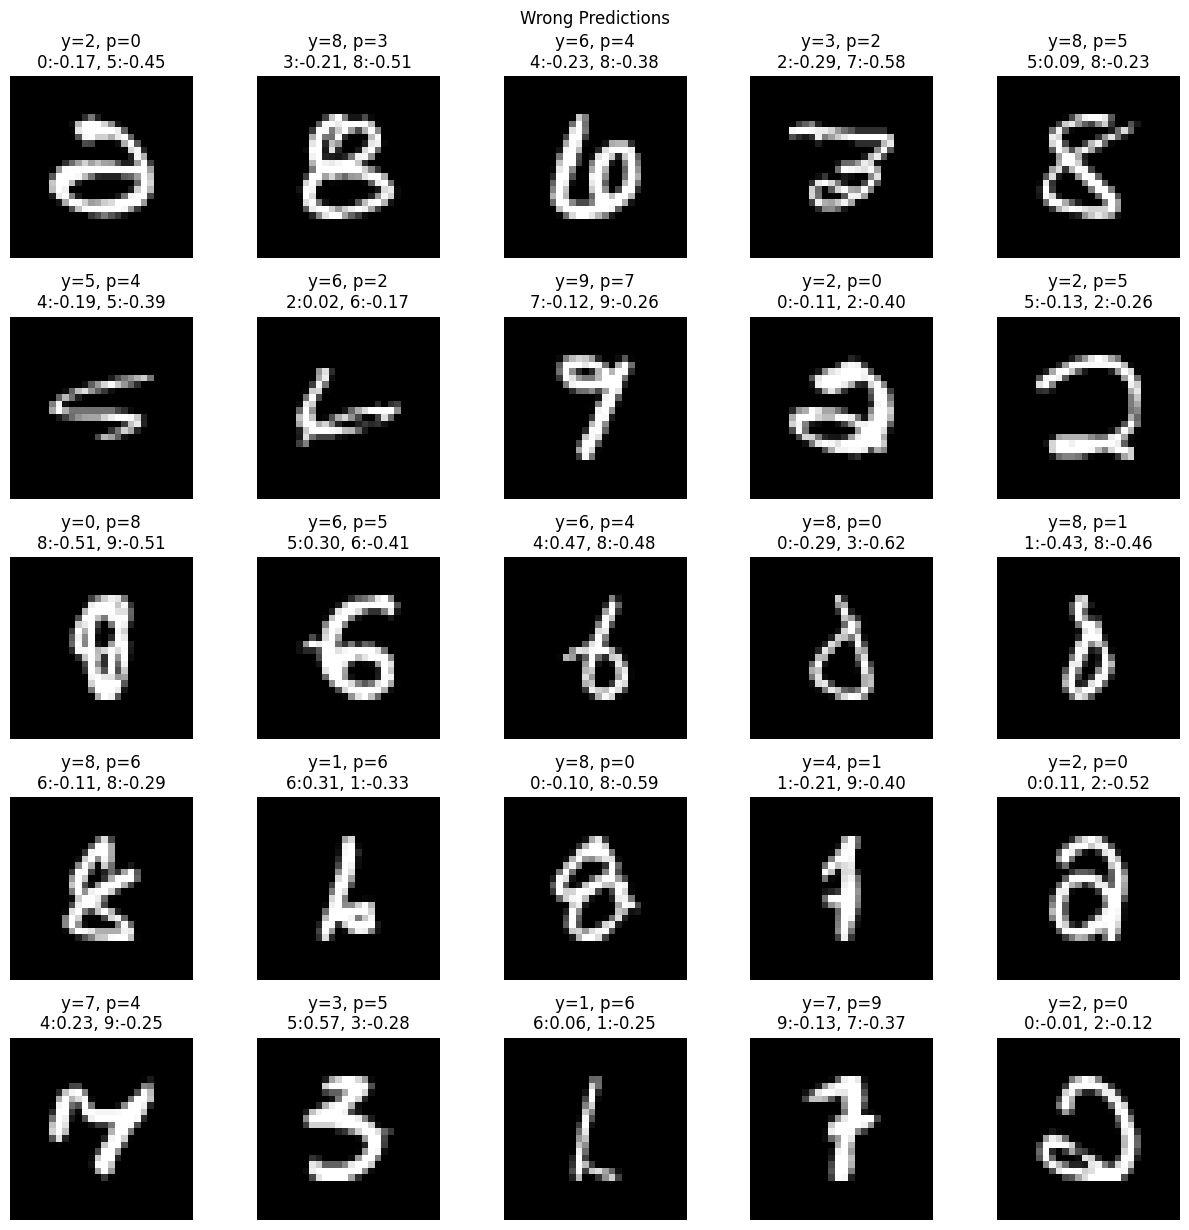

In [ ]:
# Visualize wrong predictions
def show_examples(images, labels, preds, outputs, indices, n=25, title="Examples"):
    n = min(n, len(indices))
    cols = 5
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(2.5 * cols, 2.5 * rows))
    for i in range(n):
        idx = indices[i]
        img = images[idx, 0].numpy()
        y = labels[idx].item()
        p = preds[idx].item()

        top2_vals, top2_idx = torch.topk(outputs[idx], k=2)
        s1, s2 = top2_vals.tolist()
        c1, c2 = top2_idx.tolist()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
        plt.title(f"y={y}, p={p}\n{c1}:{s1:.2f}, {c2}:{s2:.2f}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


wrong_idx = torch.where(preds != labels)[0]
print("num wrong:", len(wrong_idx))

show_examples(
    images, labels, preds, outputs,
    wrong_idx.tolist(),
    n=25,
    title="Wrong Predictions"
)

num rejected: 282


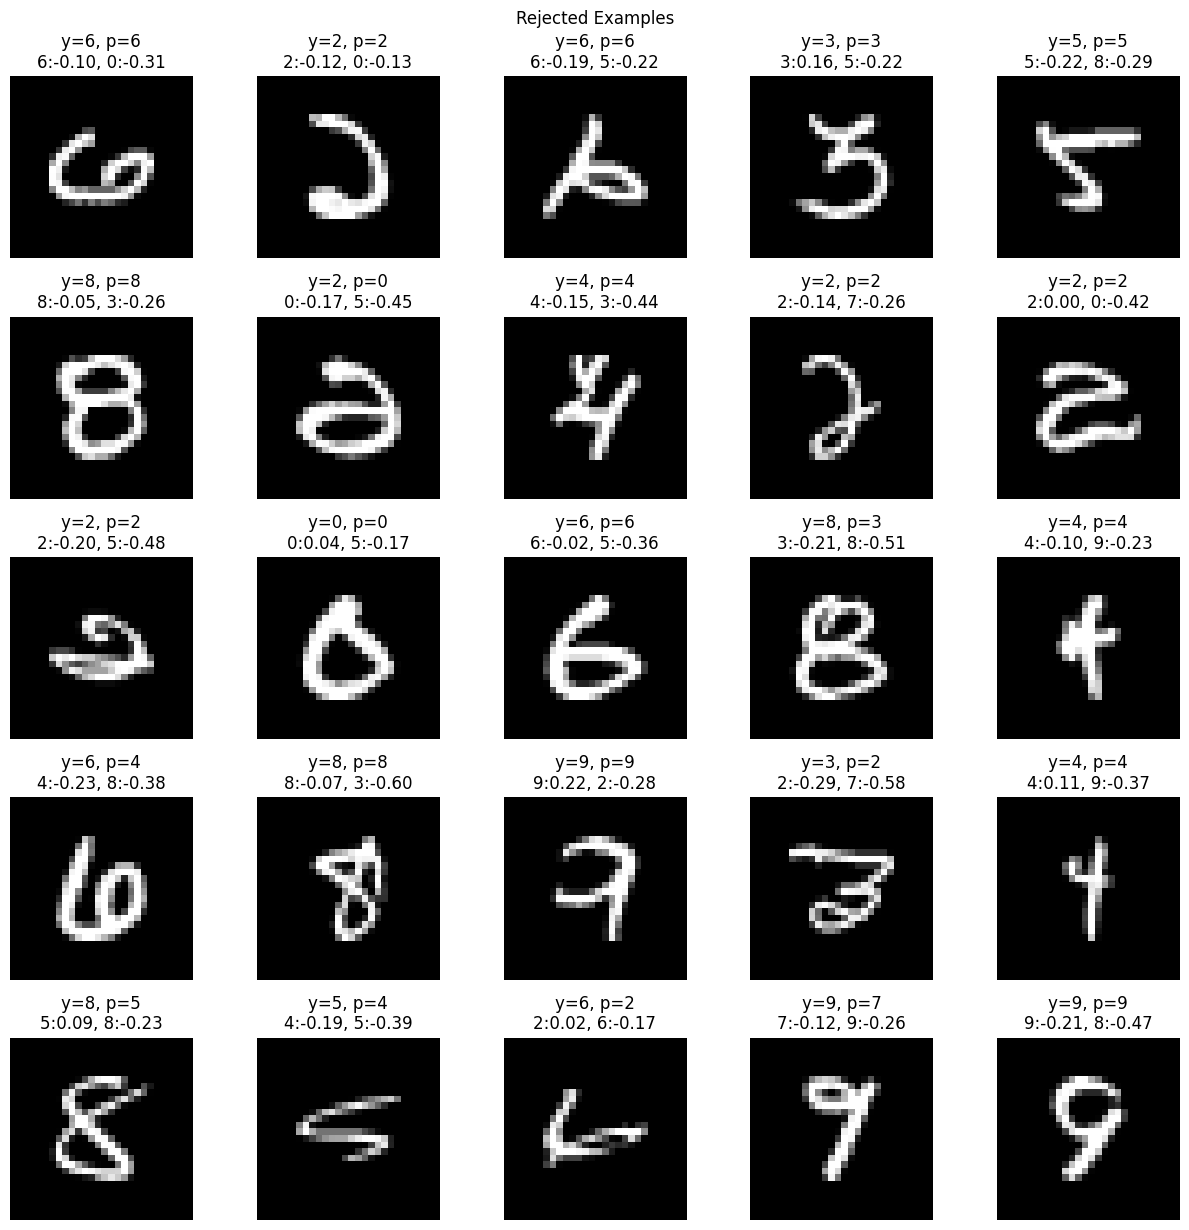

In [ ]:
# Rejection evaluator on saved outputs
#    reject unless:
#      top1 > t1
#      top2 < t2
#      (top1 - top2) > td
def rejection_stats_from_outputs(outputs, labels, t1, t2, td):
    top2_vals, top2_idx = torch.topk(outputs, k=2, dim=1)
    top1 = top2_vals[:, 0]
    top2 = top2_vals[:, 1]
    pred = top2_idx[:, 0]

    accept = (top1 > t1) & (top2 < t2) & ((top1 - top2) > td)
    reject = ~accept

    total = len(labels)
    accepted = accept.sum().item()
    rejected = reject.sum().item()

    if accepted > 0:
        accepted_correct = (pred[accept] == labels[accept]).sum().item()
        accepted_acc = accepted_correct / accepted
        accepted_err = 1 - accepted_acc
    else:
        accepted_acc = np.nan
        accepted_err = np.nan

    return {
        "t1": float(t1),
        "t2": float(t2),
        "td": float(td),
        "total": total,
        "accepted": accepted,
        "rejected": rejected,
        "accept_mask": accept,
        "reject_mask": reject,
        "reject_rate": rejected / total,
        "accept_rate": accepted / total,
        "accepted_accuracy": accepted_acc,
        "accepted_error": accepted_err,
    }


# Visualize rejected examples
# Define example_res for visualization purposes
example_res = rejection_stats_from_outputs(outputs, labels, t1=0.0, t2=0.0, td=0.5)
rejected_idx = torch.where(example_res["reject_mask"])[0]
print("num rejected:", len(rejected_idx))

show_examples(
    images, labels, preds, outputs,
    rejected_idx.tolist(),
    n=25,
    title="Rejected Examples"
)


# Sweep thresholds and build reject/error curve
def sweep_rejection(outputs, labels,
                    t1_vals=None,
                    t2_vals=None,
                    td_vals=None):
    if t1_vals is None:
        t1_vals = np.linspace(-1.0, 1.0, 21)
    if t2_vals is None:
        t2_vals = np.linspace(-1.0, 1.0, 21)
    if td_vals is None:
        td_vals = np.linspace(0.0, 2.0, 21)

    results = []
    for t1 in t1_vals:
        for t2 in t2_vals:
            for td in td_vals:
                r = rejection_stats_from_outputs(outputs, labels, t1, t2, td)
                results.append({
                    "t1": r["t1"],
                    "t2": r["t2"],
                    "td": r["td"],
                    "accepted": r["accepted"],
                    "rejected": r["rejected"],
                    "reject_rate": r["reject_rate"],
                    "accept_rate": r["accept_rate"],
                    "accepted_accuracy": r["accepted_accuracy"],
                    "accepted_error": r["accepted_error"],
                })
    return results


results = sweep_rejection(outputs, labels)

best thresholds for <=1% accepted error:
{'t1': 0.20000000000000018, 't2': -0.09999999999999998, 'td': 0.4, 'accepted': 1660, 'rejected': 347, 'reject_rate': 0.17289486796213255, 'accept_rate': 0.8271051320378675, 'accepted_accuracy': 0.9903614457831326, 'accepted_error': 0.009638554216867434}


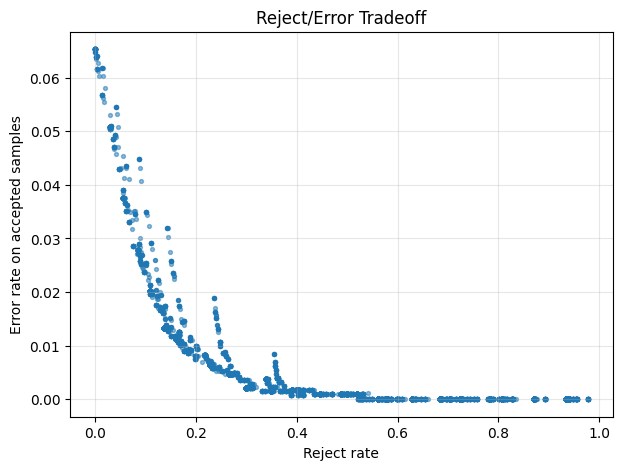

In [ ]:
# Find best point for <= 1% accepted error
valid = [
    r for r in results
    if not np.isnan(r["accepted_error"]) and r["accepted_error"] <= 0.01
]

if len(valid) > 0:
    best = min(valid, key=lambda r: r["reject_rate"])
    print("best thresholds for <=1% accepted error:")
    print(best)
else:
    print("No threshold triple reached <= 1% accepted error.")


# Plot reject rate vs accepted error
def plot_reject_error_curve(results):
    xs = []
    ys = []

    for r in results:
        if not np.isnan(r["accepted_error"]):
            xs.append(r["reject_rate"])
            ys.append(r["accepted_error"])

    plt.figure(figsize=(7, 5))
    plt.scatter(xs, ys, s=8, alpha=0.5)
    plt.xlabel("Reject rate")
    plt.ylabel("Error rate on accepted samples")
    plt.title("Reject/Error Tradeoff")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_reject_error_curve(results)

## Improvement: Modern LeNet with BatchNorm, ReLU, Dropout, Adam

**Key architectural changes over LeCun 1989:**
1. **Wider filters**: 4→16 (H1), 12→32 (H3) — more capacity to learn discriminative features
2. **ReLU** instead of tanh — avoids saturation, faster convergence
3. **Batch Normalization** after each conv — stabilizes training, acts as regularizer
4. **MaxPool** instead of trainable subsampling — stronger spatial invariance
5. **Dropout (0.25)** before FC layers — regularization for small dataset
6. **Adam optimizer** with weight decay + cosine LR schedule
7. **Hidden FC layer** (128 units) — nonlinear classifier head vs single linear layer

Still uses **MSE loss with ±1 targets** to match the original evaluation protocol.

In [ ]:
class ImprovedLeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=0),   # 28 -> 24
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 24 -> 12
            nn.Conv2d(16, 32, kernel_size=5, padding=0),  # 12 -> 8
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 8 -> 4
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(32 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

improved_model = ImprovedLeNet().to(device)
print(f"Improved model params: {sum(p.numel() for p in improved_model.parameters())}")

Improved model params: 80298


epoch 01 | train_mse=0.0787 train_acc=0.9562 | test_mse=0.0966 test_acc=0.9273
epoch 02 | train_mse=0.0538 train_acc=0.9786 | test_mse=0.0730 test_acc=0.9462
epoch 03 | train_mse=0.0420 train_acc=0.9844 | test_mse=0.0607 test_acc=0.9522
epoch 04 | train_mse=0.0306 train_acc=0.9903 | test_mse=0.0484 test_acc=0.9596
epoch 05 | train_mse=0.0249 train_acc=0.9881 | test_mse=0.0430 test_acc=0.9596
epoch 06 | train_mse=0.0274 train_acc=0.9929 | test_mse=0.0457 test_acc=0.9656
epoch 07 | train_mse=0.0230 train_acc=0.9930 | test_mse=0.0417 test_acc=0.9651
epoch 08 | train_mse=0.0198 train_acc=0.9940 | test_mse=0.0379 test_acc=0.9661
epoch 09 | train_mse=0.0187 train_acc=0.9947 | test_mse=0.0372 test_acc=0.9661
epoch 10 | train_mse=0.0179 train_acc=0.9944 | test_mse=0.0368 test_acc=0.9716
epoch 11 | train_mse=0.0164 train_acc=0.9960 | test_mse=0.0352 test_acc=0.9656
epoch 12 | train_mse=0.0148 train_acc=0.9964 | test_mse=0.0332 test_acc=0.9691
epoch 13 | train_mse=0.0161 train_acc=0.9962 | test_

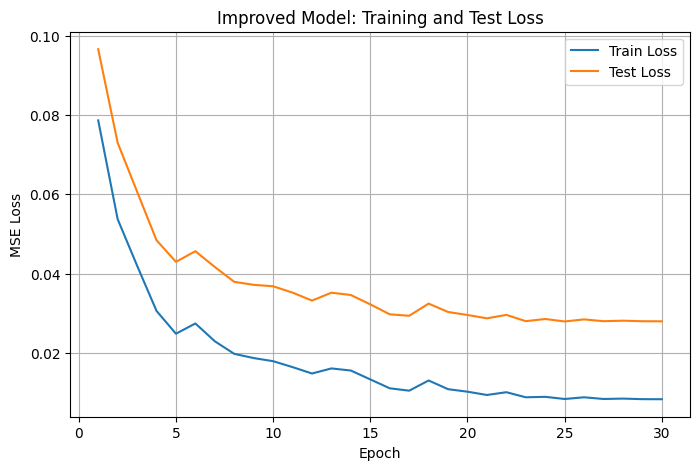

In [ ]:
# Train improved model
criterion_imp = nn.MSELoss()
optimizer_imp = torch.optim.Adam(improved_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_imp = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_imp, T_max=30)

best_acc_imp = 0
best_state_imp = None

train_mse_history_imp = []
test_mse_history_imp = []

for epoch in range(30):
    improved_model.train()
    for xb, yb, tb in train_loader:
        xb = xb.to(device)
        tb = tb.to(device)

        optimizer_imp.zero_grad()
        out = improved_model(xb)
        loss = criterion_imp(out, tb)
        loss.backward()
        optimizer_imp.step()

    scheduler_imp.step()

    train_mse, train_acc = evaluate(improved_model, train_loader, criterion_imp)
    test_mse, test_acc = evaluate(improved_model, test_loader, criterion_imp)

    train_mse_history_imp.append(train_mse)
    test_mse_history_imp.append(test_mse)

    if test_acc > best_acc_imp:
        best_acc_imp = test_acc
        best_state_imp = {k: v.clone() for k, v in improved_model.state_dict().items()}

    print(
        f"epoch {epoch+1:02d} | "
        f"train_mse={train_mse:.4f} train_acc={train_acc:.4f} | "
        f"test_mse={test_mse:.4f} test_acc={test_acc:.4f}"
    )

# Restore best checkpoint
improved_model.load_state_dict(best_state_imp)

# Plot losses
epochs = range(1, len(train_mse_history_imp) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_mse_history_imp, label="Train Loss")
plt.plot(epochs, test_mse_history_imp, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Improved Model: Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate improved model
images_imp, labels_imp, targets_imp, outputs_imp, preds_imp = collect_outputs(
    improved_model, test_loader, device=device
)

metrics_imp = basic_metrics(outputs_imp, labels_imp, targets_imp)
print("Improved model metrics:", metrics_imp)
print()
print("Baseline (LeCun 1989):")
print("  mse=0.07353, acc=0.93473, err=0.06527")
print()
print(f"Improvement:")
print(f"  MSE:  {0.07353 - metrics_imp['mse']:.5f} reduction")
print(f"  Acc:  {metrics_imp['acc'] - 0.93473:.4f} improvement")
print(f"  Err:  {0.06527 - metrics_imp['err']:.4f} reduction")

Improved model metrics: {'mse': 0.03225818648934364, 'acc': 0.9725959300994873, 'err': 0.027404069900512695}

Baseline (LeCun 1989):
  mse=0.07353, acc=0.93473, err=0.06527

Improvement:
  MSE:  0.04127 reduction
  Acc:  0.0379 improvement
  Err:  0.0379 reduction


tensor([[354,   0,   1,   0,   1,   0,   0,   1,   2,   0],
        [  0, 257,   0,   0,   4,   0,   3,   0,   0,   0],
        [  1,   0, 193,   1,   1,   0,   0,   1,   1,   0],
        [  0,   0,   2, 155,   0,   8,   0,   0,   1,   0],
        [  0,   2,   2,   1, 191,   0,   2,   0,   0,   2],
        [  2,   0,   0,   2,   0, 156,   0,   0,   0,   0],
        [  0,   0,   1,   0,   1,   0, 168,   0,   0,   0],
        [  0,   0,   1,   1,   4,   0,   0, 141,   0,   0],
        [  3,   0,   1,   0,   0,   0,   0,   0, 162,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   2, 175]])


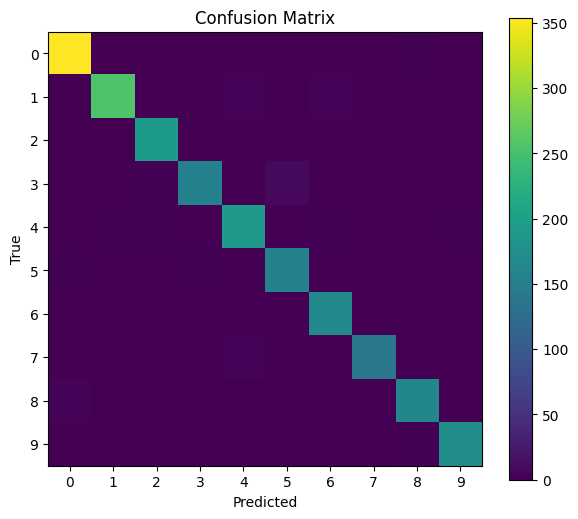

In [ ]:
# Confusion matrix for improved model
cm_imp = confusion_matrix_torch(labels_imp, preds_imp, num_classes=10)
print(cm_imp)
plot_confusion_matrix(cm_imp)

num wrong: 55 (vs 131 for baseline)


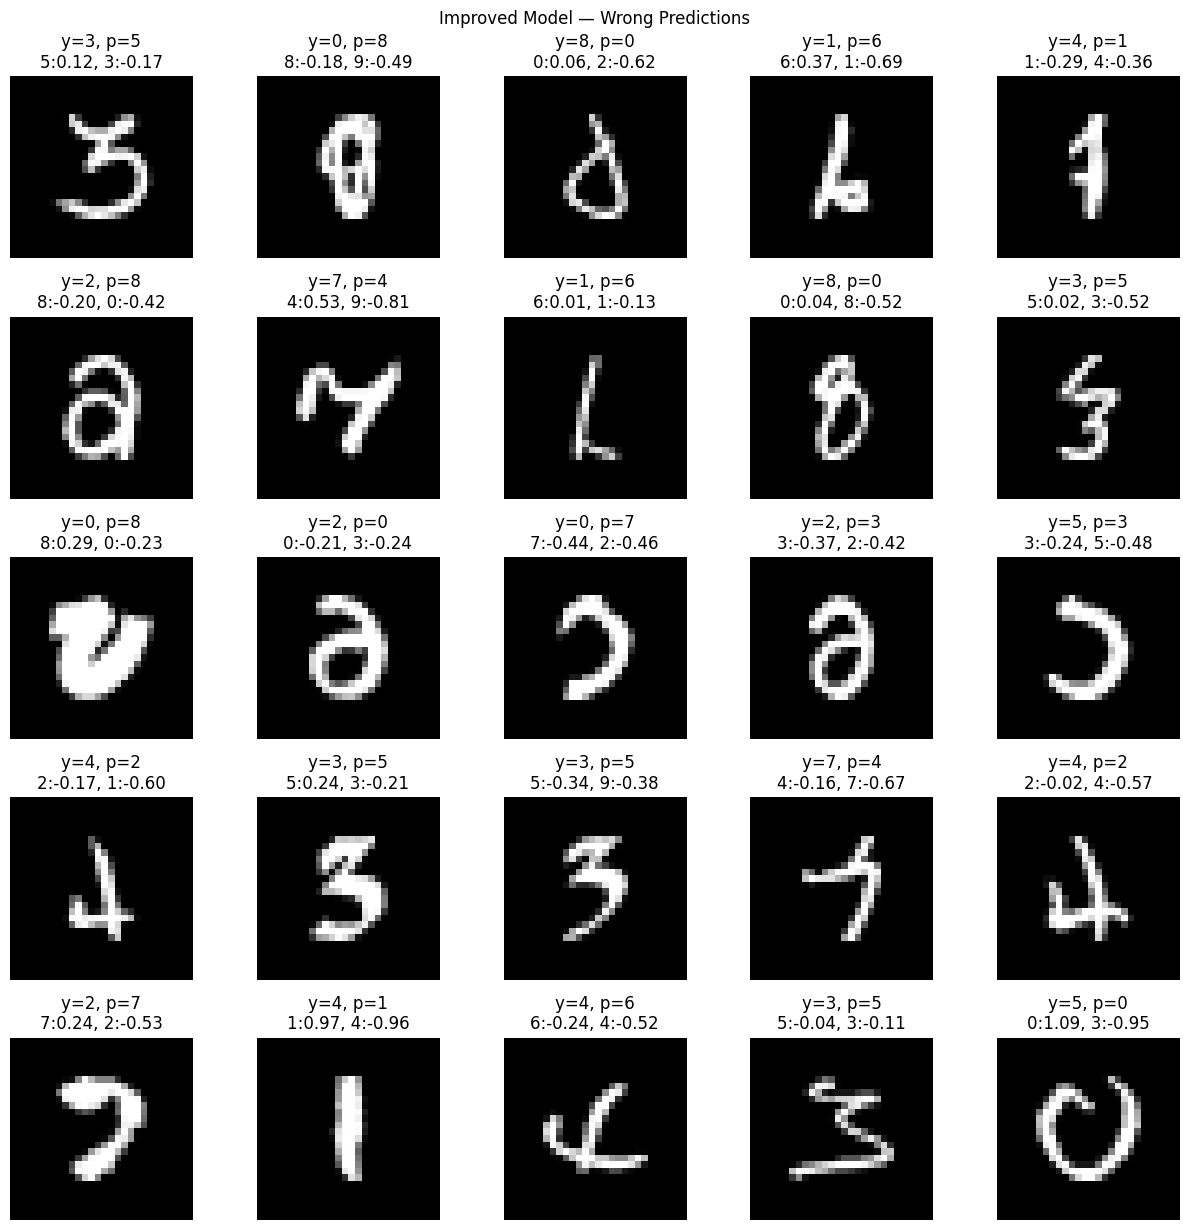

In [ ]:
# Wrong predictions for improved model
wrong_idx_imp = torch.where(preds_imp != labels_imp)[0]
print(f"num wrong: {len(wrong_idx_imp)} (vs {len(wrong_idx)} for baseline)")

show_examples(
    images_imp, labels_imp, preds_imp, outputs_imp,
    wrong_idx_imp.tolist(),
    n=25,
    title="Improved Model — Wrong Predictions"
)

Best thresholds for <=1% accepted error (improved):
{'t1': -0.09999999999999998, 't2': -0.29999999999999993, 'td': 0.0, 'accepted': 1917, 'rejected': 90, 'reject_rate': 0.04484304932735426, 'accept_rate': 0.9551569506726457, 'accepted_accuracy': 0.9900886802295253, 'accepted_error': 0.009911319770474658}


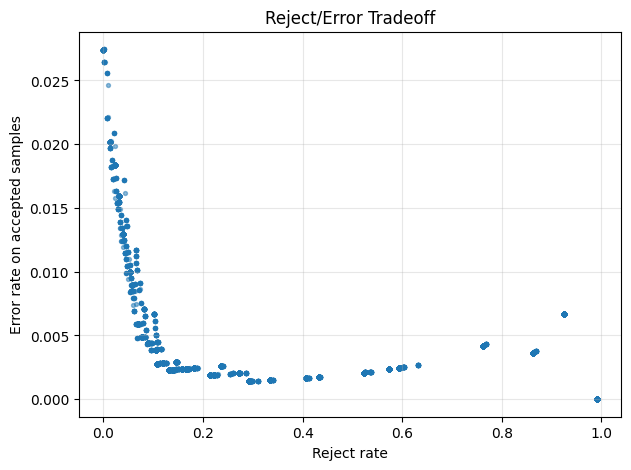

In [ ]:
# Rejection sweep for improved model
results_imp = sweep_rejection(outputs_imp, labels_imp)

valid_imp = [
    r for r in results_imp
    if not np.isnan(r['accepted_error']) and r['accepted_error'] <= 0.01
]

if len(valid_imp) > 0:
    best_imp = min(valid_imp, key=lambda r: r['reject_rate'])
    print('Best thresholds for <=1% accepted error (improved):')
    print(best_imp)
else:
    print('No threshold triple reached <= 1% accepted error.')

plot_reject_error_curve(results_imp)